<h1 style="text-align: center; background-color: #1e86cc; border-radius: 30px; padding: 10px;">COSC2753 - Machine Learning</h1>
<h2 style="text-align: center;">Assignment 1 - Chatbot Data Analysis</h2>
<h3 style="text-align: center;">Author: Nguyen Gia Khang</h3>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

In [3]:
chatbot_data = pd.read_csv('./inputs/train.csv')

In [4]:
chatbot_data

,RecordID,TARGET_Capacity,CaseCount,Country,Year,Status,SystemFailureRate,ModelFailureRate-T,ModelFailureRate-NT,InferenceLatency,ComputeUtilizationRate,AIInfraExpPercent,SecurityBreachIncidents,IntegrationEfficiency,UptimeReliabilityIndex,AILearningStability,AIDevExpPercent,PatchCoverageRate,SystemVulnerabilityScore,GlobalAdoptionIndex,ActiveUserBase,TeenQueryEfficiency,ChildQueryEfficiency,FundingDiversityIndex,DatasetDiversityScore,Complexity
0,1,54.5,19.0,146,2007.0,0,291,306,276.0,85,0.02,1.388648,1296,14.2,118,58,8.70,58.0,0.1,28.33,257798.0,19.3,19.5,0.396,2.810694,1.152688
1,2,58.5,23.0,146,2006.0,0,293,286,300.0,87,0.02,15.296066,466,13.8,120,5,8.79,5.0,0.1,245.44,24118979.0,19.5,19.7,0.381,2.607681,1.140279
2,3,53.9,18.0,146,2005.0,0,295,326,264.0,87,0.01,11.089053,798,13.4,122,41,8.82,41.0,0.1,222.58,2364851.0,19.7,19.9,0.373,2.549510,1.127205
3,4,58.4,22.0,146,2004.0,0,3,2,4.0,88,0.01,16.887351,2486,13.0,122,36,7.76,36.0,0.1,210.39,21979923.0,19.9,2.2,0.341,2.489980,1.114043
4,5,55.2,19.0,146,2003.0,0,316,312,320.0,88,0.01,10.574728,8762,12.6,122,35,7.80,33.0,0.1,131.60,2966463.0,2.1,2.4,0.340,2.428992,1.100471
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2066,2067,47.7,12.0,61,2006.0,0,578,596,560.0,36,2.46,8.369852,35,18.0,59,84,7.33,83.0,17.6,59.67,11731746.0,7.2,7.1,0.456,3.240370,7.306873
2067,2068,46.0,10.0,61,2005.0,0,64,66,62.0,39,2.33,65.789974,881,17.6,62,85,8.18,83.0,18.2,480.66,11421984.0,7.3,7.2,0.443,3.193744,6.674413
2068,2069,46.2,10.0,61,2004.0,0,69,70,68.0,41,2.44,54.043480,25036,17.3,66,85,6.93,84.0,18.4,422.39,111249.0,7.4,7.3,0.433,3.162278,7.191646
2069,2070,47.1,11.0,61,2003.0,0,611,574,648.0,43,2.61,46.830275,16997,17.1,70,86,6.56,85.0,18.6,423.67,1824125.0,7.4,7.4,0.424,3.130495,8.045096


In [5]:
chatbot_data.head()

,RecordID,TARGET_Capacity,CaseCount,Country,Year,Status,SystemFailureRate,ModelFailureRate-T,ModelFailureRate-NT,InferenceLatency,ComputeUtilizationRate,AIInfraExpPercent,SecurityBreachIncidents,IntegrationEfficiency,UptimeReliabilityIndex,AILearningStability,AIDevExpPercent,PatchCoverageRate,SystemVulnerabilityScore,GlobalAdoptionIndex,ActiveUserBase,TeenQueryEfficiency,ChildQueryEfficiency,FundingDiversityIndex,DatasetDiversityScore,Complexity
0,1,54.5,19.0,146,2007.0,0,291,306,276.0,85,0.02,1.388648,1296,14.2,118,58,8.70,58.0,0.1,28.33,257798.0,19.3,19.5,0.396,2.810694,1.152688
1,2,58.5,23.0,146,2006.0,0,293,286,300.0,87,0.02,15.296066,466,13.8,120,5,8.79,5.0,0.1,245.44,24118979.0,19.5,19.7,0.381,2.607681,1.140279
2,3,53.9,18.0,146,2005.0,0,295,326,264.0,87,0.01,11.089053,798,13.4,122,41,8.82,41.0,0.1,222.58,2364851.0,19.7,19.9,0.373,2.549510,1.127205
3,4,58.4,22.0,146,2004.0,0,3,2,4.0,88,0.01,16.887351,2486,13.0,122,36,7.76,36.0,0.1,210.39,21979923.0,19.9,2.2,0.341,2.489980,1.114043
4,5,55.2,19.0,146,2003.0,0,316,312,320.0,88,0.01,10.574728,8762,12.6,122,35,7.80,33.0,0.1,131.60,2966463.0,2.1,2.4,0.340,2.428992,1.100471


In [6]:
chatbot_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2071 entries, 0 to 2070
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   RecordID                  2071 non-null   int64  
 1   TARGET_Capacity           2070 non-null   float64
 2   CaseCount                 2069 non-null   float64
 3   Country                   2071 non-null   int64  
 4   Year                      2070 non-null   float64
 5   Status                    2071 non-null   int64  
 6   SystemFailureRate         2071 non-null   int64  
 7   ModelFailureRate-T        2071 non-null   int64  
 8   ModelFailureRate-NT       2070 non-null   float64
 9   InferenceLatency          2071 non-null   int64  
 10  ComputeUtilizationRate    2071 non-null   float64
 11  AIInfraExpPercent         2071 non-null   float64
 12  SecurityBreachIncidents   2071 non-null   int64  
 13  IntegrationEfficiency     2071 non-null   float64
 14  UptimeReliabilityIn

In [7]:
chatbot_data[chatbot_data.isnull().any(axis=1)]

,RecordID,TARGET_Capacity,CaseCount,Country,Year,Status,SystemFailureRate,ModelFailureRate-T,ModelFailureRate-NT,InferenceLatency,ComputeUtilizationRate,AIInfraExpPercent,SecurityBreachIncidents,IntegrationEfficiency,UptimeReliabilityIndex,AILearningStability,AIDevExpPercent,PatchCoverageRate,SystemVulnerabilityScore,GlobalAdoptionIndex,ActiveUserBase,TeenQueryEfficiency,ChildQueryEfficiency,FundingDiversityIndex,DatasetDiversityScore,Complexity
88,89,77.4,41.0,15,NaN,0,132,128,136.0,1,3.99,44.572200,1,49.7,1,9,4.31,88.0,0.1,3515.55,293356.0,2.0,2.1,0.707,3.420526,17.616456
169,170,73.0,37.0,176,2008.0,0,243,236,NaN,1,12.60,364.426052,149,57.2,1,97,6.34,99.0,0.1,4310.00,964924.0,2.2,2.4,0.723,3.820995,160.517396
231,232,65.8,30.0,117,2010.0,0,234,228,240.0,1,0.21,302.667579,7,18.8,1,96,6.58,96.0,0.4,2010.60,NaN,17.1,17.8,0.000,3.240370,1.318258
297,298,73.7,38.0,170,2008.0,1,161,164,158.0,1,10.39,508.630459,1,6.3,1,96,6.67,95.0,0.1,5054.71,76122.0,2.2,2.2,0.750,NaN,108.751441
313,314,52.0,16.0,27,2008.0,0,32,34,30.0,47,4.73,64.240252,125,14.6,86,94,6.58,86.0,2.0,473.35,13829177.0,1.0,9.6,0.325,2.167948,NaN
314,315,53.4,17.0,27,2007.0,0,313,316,310.0,48,4.88,8.769989,253,14.2,89,94,NaN,82.0,2.3,52.64,1342193.0,1.3,9.8,0.000,2.073644,24.966688
318,319,55.6,NaN,27,2003.0,0,344,364,324.0,48,4.56,23.101690,4174,12.5,93,62,4.85,62.0,3.6,263.75,11944587.0,11.2,1.8,0.000,1.870829,21.890510
330,331,NaN,22.0,95,2007.0,0,369,386,352.0,24,5.54,1.747441,0,14.1,37,82,9.84,87.0,4.3,17.44,7423289.0,8.2,8.3,0.286,2.366432,31.840819
942,943,73.0,NaN,43,2004.0,0,167,160,174.0,1,3.76,211.114332,0,43.5,1,99,4.86,99.0,2.3,4028.08,2695446.0,2.0,1.8,0.690,3.420526,15.776089
1190,1191,75.8,40.0,111,2012.0,0,73,74,72.0,0,1.83,91.139718,0,22.1,0,97,7.93,96.0,0.1,709.85,367.0,14.0,14.1,0.653,3.405877,NaN


In [8]:
print(f"Duplicate rows: {chatbot_data.duplicated().sum()}")

Duplicate rows: 0


In [9]:
chatbot_data.describe(include="all")

,RecordID,TARGET_Capacity,CaseCount,Country,Year,Status,SystemFailureRate,ModelFailureRate-T,ModelFailureRate-NT,InferenceLatency,ComputeUtilizationRate,AIInfraExpPercent,SecurityBreachIncidents,IntegrationEfficiency,UptimeReliabilityIndex,AILearningStability,AIDevExpPercent,PatchCoverageRate,SystemVulnerabilityScore,GlobalAdoptionIndex,ActiveUserBase,TeenQueryEfficiency,ChildQueryEfficiency,FundingDiversityIndex,DatasetDiversityScore,Complexity
count,2071.000000,2070.000000,2069.000000,2071.000000,2070.000000,2071.000000,2071.000000,2071.000000,2070.000000,2071.000000,2071.000000,2071.000000,2071.000000,2071.000000,2071.000000,2071.000000,2070.000000,2071.000000,2071.000000,2071.000000,2.070000e+03,2071.000000,2071.000000,2071.000000,2070.000000,2069.000000
mean,1036.000000,69.280000,33.333011,95.360212,2009.518841,0.192178,163.198938,161.908257,163.717874,33.079672,4.696379,764.540216,2095.747948,37.530662,45.886045,82.727185,5.883382,82.753259,1.632883,7350.672269,1.204323e+07,4.955625,4.977306,0.609551,3.372308,41.235455
std,597.990524,9.481274,9.488045,54.861641,4.615248,0.506724,119.787231,119.442235,118.813864,135.832868,4.205888,2081.880374,9959.531347,19.945437,185.254990,23.188837,2.555490,23.130969,4.782325,15220.687350,6.393286e+07,4.728884,4.785532,0.216532,0.590938,52.618343
min,1.000000,37.300000,1.000000,0.000000,2002.000000,0.000000,1.000000,0.000000,2.000000,0.000000,0.010000,0.000000,0.000000,1.000000,0.000000,3.000000,0.370000,2.000000,0.100000,0.000000,3.400000e+01,0.100000,0.100000,0.000000,0.000000,0.146228
25%,518.500000,63.000000,27.000000,50.000000,2006.000000,0.000000,74.000000,74.000000,74.000000,0.000000,0.615000,5.848550,0.000000,18.700000,0.000000,77.000000,4.185000,78.000000,0.100000,413.730000,1.274450e+05,1.600000,1.500000,0.463000,3.065942,2.038296
50%,1036.000000,71.200000,35.000000,94.000000,2010.000000,0.000000,144.000000,142.000000,144.000000,3.000000,3.830000,69.020425,19.000000,42.000000,4.000000,93.000000,5.640000,93.000000,0.100000,1397.330000,6.525915e+05,3.200000,3.300000,0.655000,3.449638,16.085911
75%,1553.500000,76.000000,40.000000,144.000000,2014.000000,0.000000,228.000000,228.000000,230.000000,22.000000,7.840000,430.190047,427.000000,55.900000,27.000000,97.000000,7.430000,97.000000,0.800000,5811.295000,5.373518e+06,7.400000,7.400000,0.769500,3.741657,63.144118
max,2071.000000,92.700000,57.000000,192.000000,2017.000000,15.000000,840.000000,704.000000,722.000000,1800.000000,17.870000,19479.911610,212183.000000,87.300000,2500.000000,99.000000,17.600000,99.000000,50.600000,133473.470000,1.293859e+09,30.000000,28.600000,0.948000,4.381780,321.087408


In [10]:
# Check each feature to see how many negative values
neg_counts = []

for column in chatbot_data.columns:
    if chatbot_data[column].dtype in ["int64", "float64"]:
        neg_counts.append({
            "Feature": column,
            "Negative Count": (chatbot_data[column] < 0).sum()
        })

neg_table = pd.DataFrame(neg_counts)
neg_table

,Feature,Negative Count
0,RecordID,0
1,TARGET_Capacity,0
2,CaseCount,0
3,Country,0
4,Year,0
5,Status,0
6,SystemFailureRate,0
7,ModelFailureRate-T,0
8,ModelFailureRate-NT,0
9,InferenceLatency,0


Define rows with Status different from 0 and 1

In [11]:
rows_with_status_not_0_or_1 = chatbot_data[~chatbot_data['Status'].isin([0, 1])]
rows_with_status_not_0_or_1

,RecordID,TARGET_Capacity,CaseCount,Country,Year,Status,SystemFailureRate,ModelFailureRate-T,ModelFailureRate-NT,InferenceLatency,ComputeUtilizationRate,AIInfraExpPercent,SecurityBreachIncidents,IntegrationEfficiency,UptimeReliabilityIndex,AILearningStability,AIDevExpPercent,PatchCoverageRate,SystemVulnerabilityScore,GlobalAdoptionIndex,ActiveUserBase,TeenQueryEfficiency,ChildQueryEfficiency,FundingDiversityIndex,DatasetDiversityScore,Complexity
441,442,77.7,42.0,151,2008.0,15,113,116,110.0,0,11.83,1555.651986,1,58.1,0,96,6.95,96.0,0.1,12727.03,444.0,1.8,1.8,0.783,3.72827,141.713076


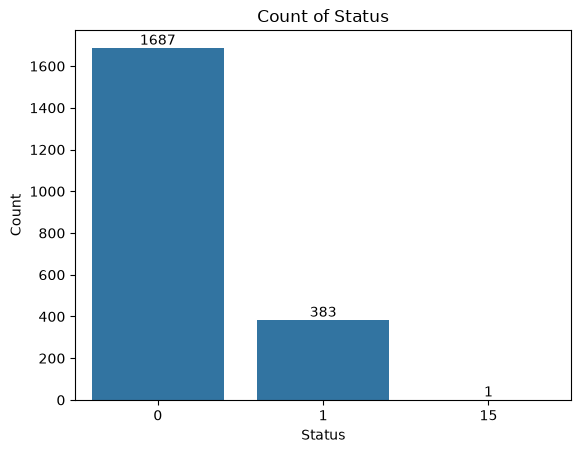

In [12]:
ax = sns.countplot(data=chatbot_data, x="Status")
plt.title("Count of Status")
plt.xlabel("Status")
plt.ylabel("Count")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

Drop rows with missing values

In [13]:
chatbot_data.dropna(inplace=True)

Drop rows with Status different from 0 and 1

In [14]:
chatbot_data = chatbot_data[chatbot_data['Status'].isin([0, 1])]

Drop the 'RecordID' column as it is not useful for analysis

In [15]:
chatbot_data.drop(['RecordID'], axis=1, inplace=True)

### Split the data into training and testing sets

In [16]:
from sklearn.model_selection import train_test_split

target = "TARGET_Capacity"

X = chatbot_data.drop(columns=[target])
y = chatbot_data[target]

X_train: pd.DataFrame
X_test: pd.DataFrame
y_train: pd.Series
y_test: pd.Series

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
training_data = pd.concat([X_train, y_train], axis=1)
testing_data = pd.concat([X_test, y_test], axis=1)

In [18]:
training_data.info()

<class 'pandas.DataFrame'>
Index: 1648 entries, 269 to 869
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CaseCount                 1648 non-null   float64
 1   Country                   1648 non-null   int64  
 2   Year                      1648 non-null   float64
 3   Status                    1648 non-null   int64  
 4   SystemFailureRate         1648 non-null   int64  
 5   ModelFailureRate-T        1648 non-null   int64  
 6   ModelFailureRate-NT       1648 non-null   float64
 7   InferenceLatency          1648 non-null   int64  
 8   ComputeUtilizationRate    1648 non-null   float64
 9   AIInfraExpPercent         1648 non-null   float64
 10  SecurityBreachIncidents   1648 non-null   int64  
 11  IntegrationEfficiency     1648 non-null   float64
 12  UptimeReliabilityIndex    1648 non-null   int64  
 13  AILearningStability       1648 non-null   int64  
 14  AIDevExpPercent        

In [19]:
testing_data.info()

<class 'pandas.DataFrame'>
Index: 412 entries, 1310 to 1797
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CaseCount                 412 non-null    float64
 1   Country                   412 non-null    int64  
 2   Year                      412 non-null    float64
 3   Status                    412 non-null    int64  
 4   SystemFailureRate         412 non-null    int64  
 5   ModelFailureRate-T        412 non-null    int64  
 6   ModelFailureRate-NT       412 non-null    float64
 7   InferenceLatency          412 non-null    int64  
 8   ComputeUtilizationRate    412 non-null    float64
 9   AIInfraExpPercent         412 non-null    float64
 10  SecurityBreachIncidents   412 non-null    int64  
 11  IntegrationEfficiency     412 non-null    float64
 12  UptimeReliabilityIndex    412 non-null    int64  
 13  AILearningStability       412 non-null    int64  
 14  AIDevExpPercent       

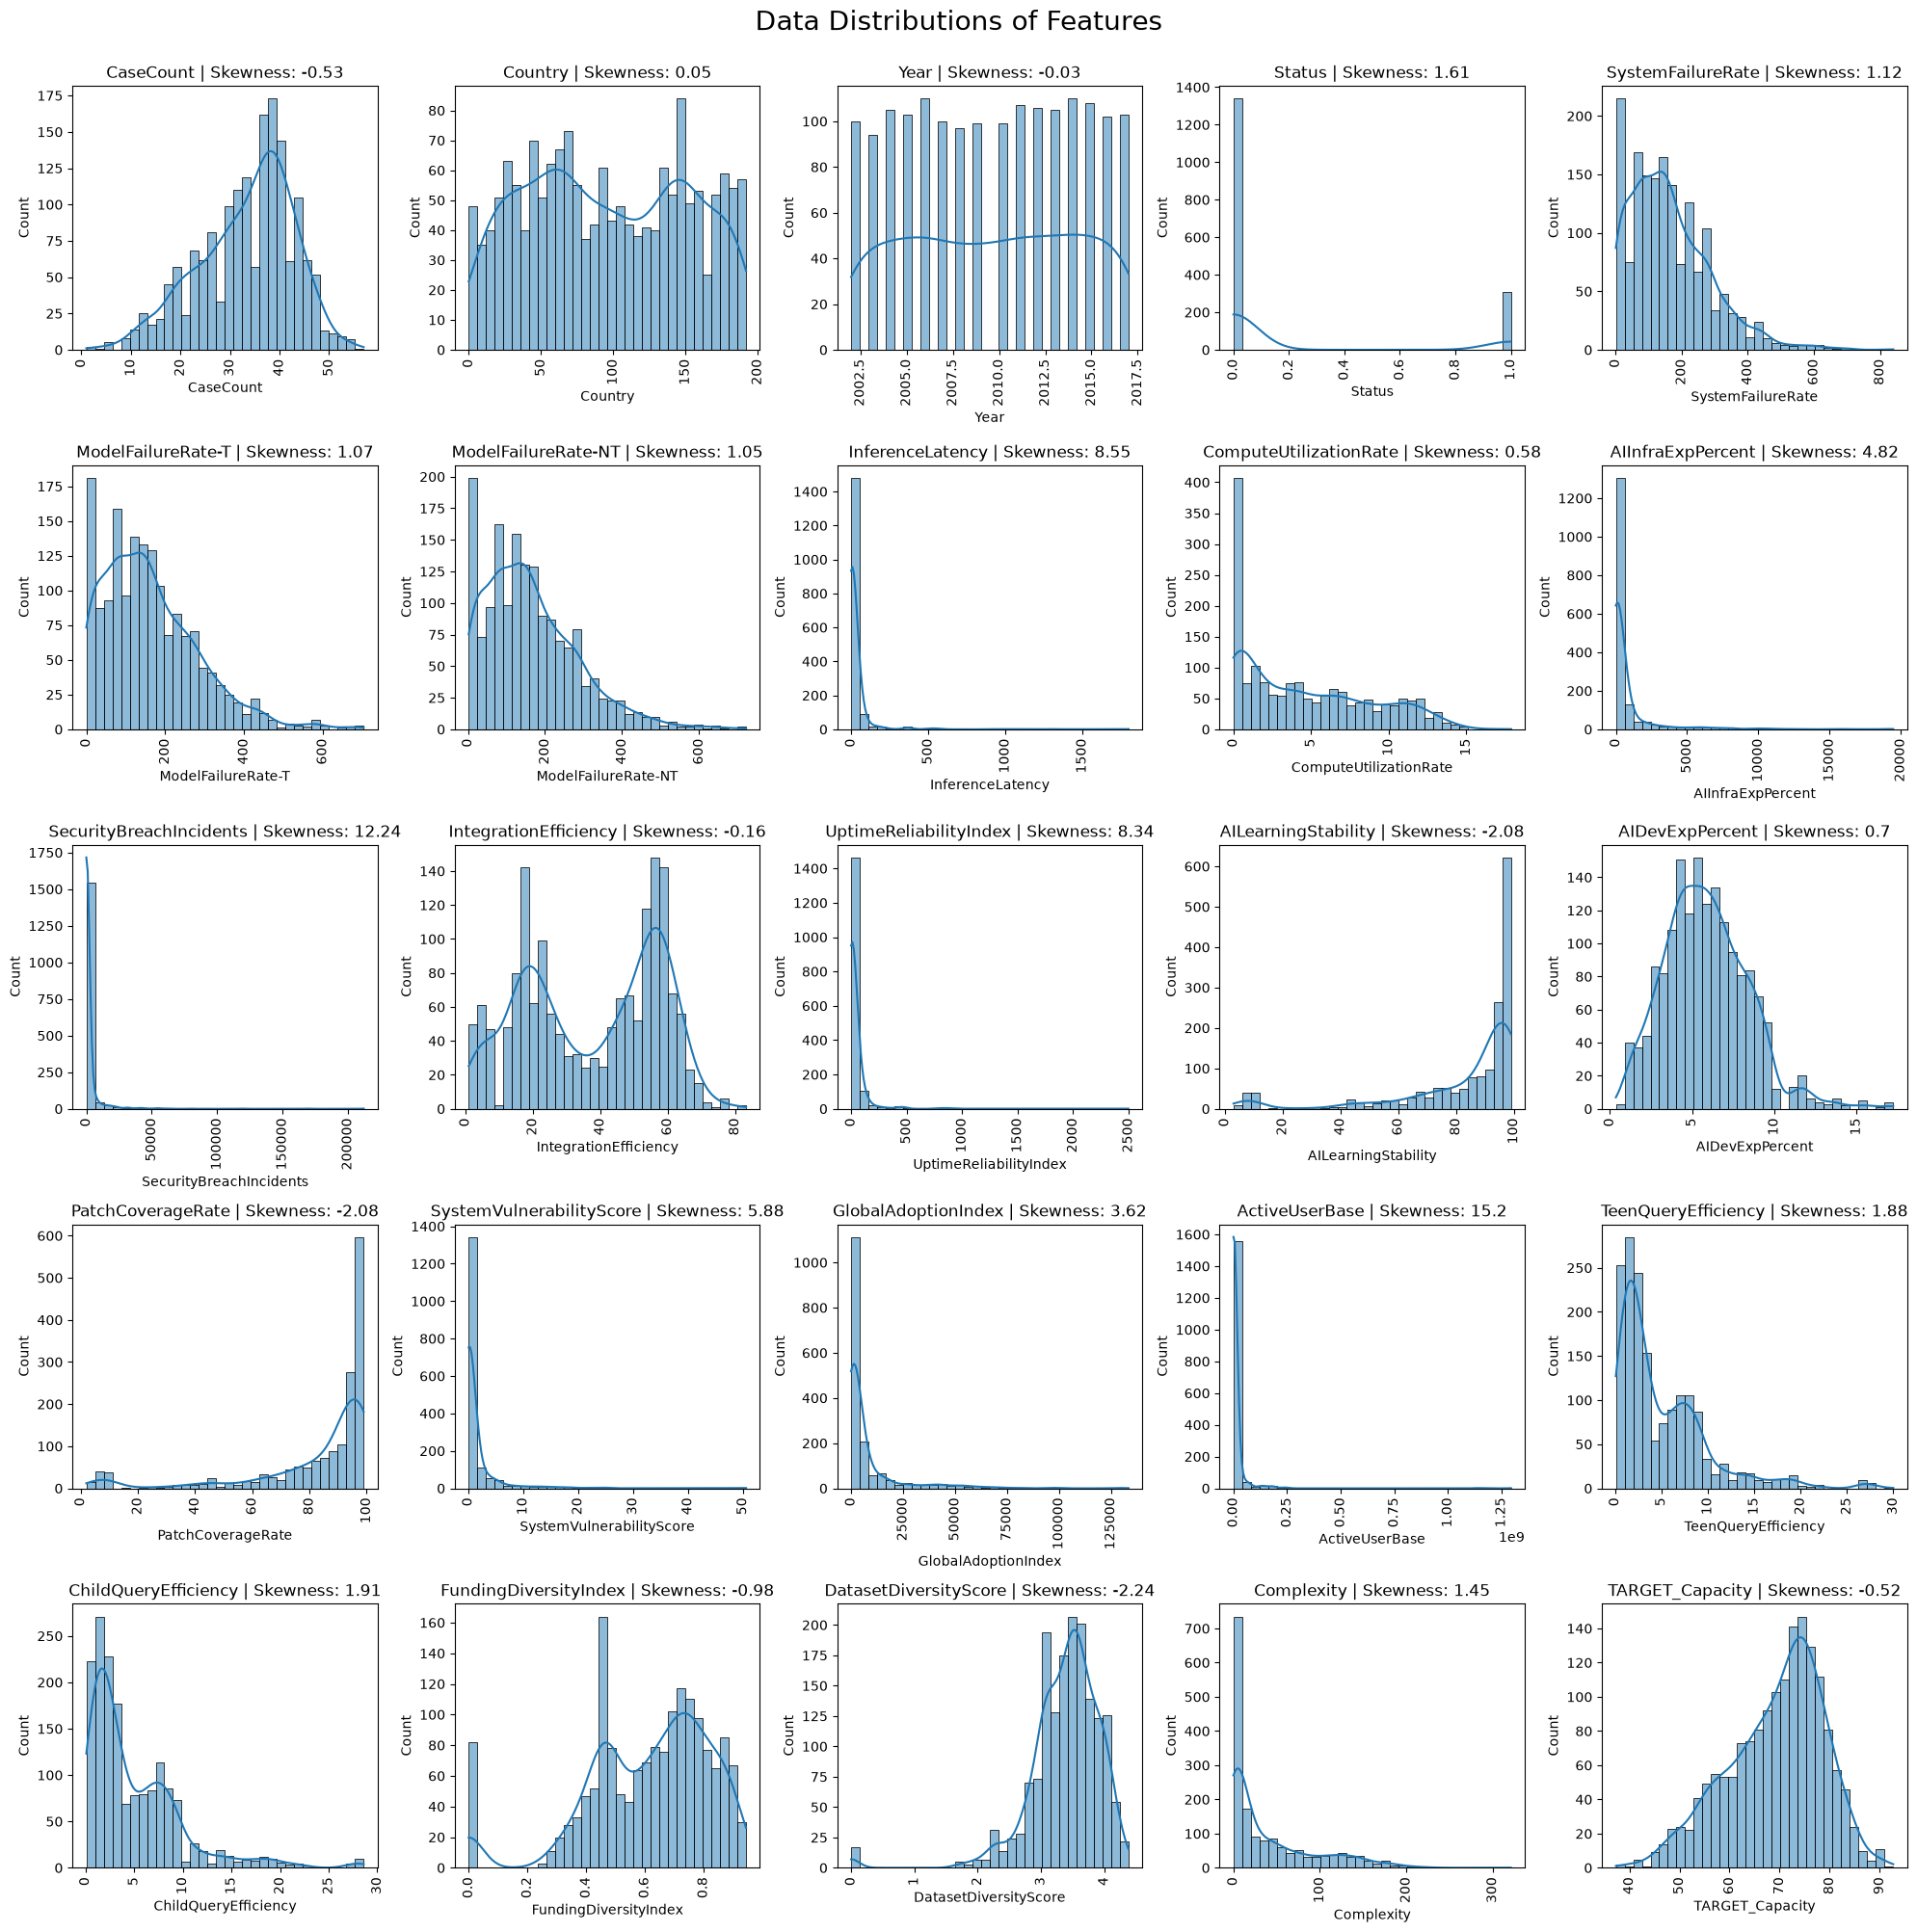

In [20]:
plt.figure(figsize=(20,20))
for i, col in enumerate(training_data.columns):
    plt.subplot(5,5,i+1)
    sns.histplot(training_data[col], kde=True, bins=32)
    plt.title(f"{col} | Skewness: {round(training_data[col].skew(), 2)}")
    plt.xticks(rotation='vertical')

plt.suptitle("Data Distributions of Features", y=1, fontsize=20)
plt.tight_layout()
plt.show()

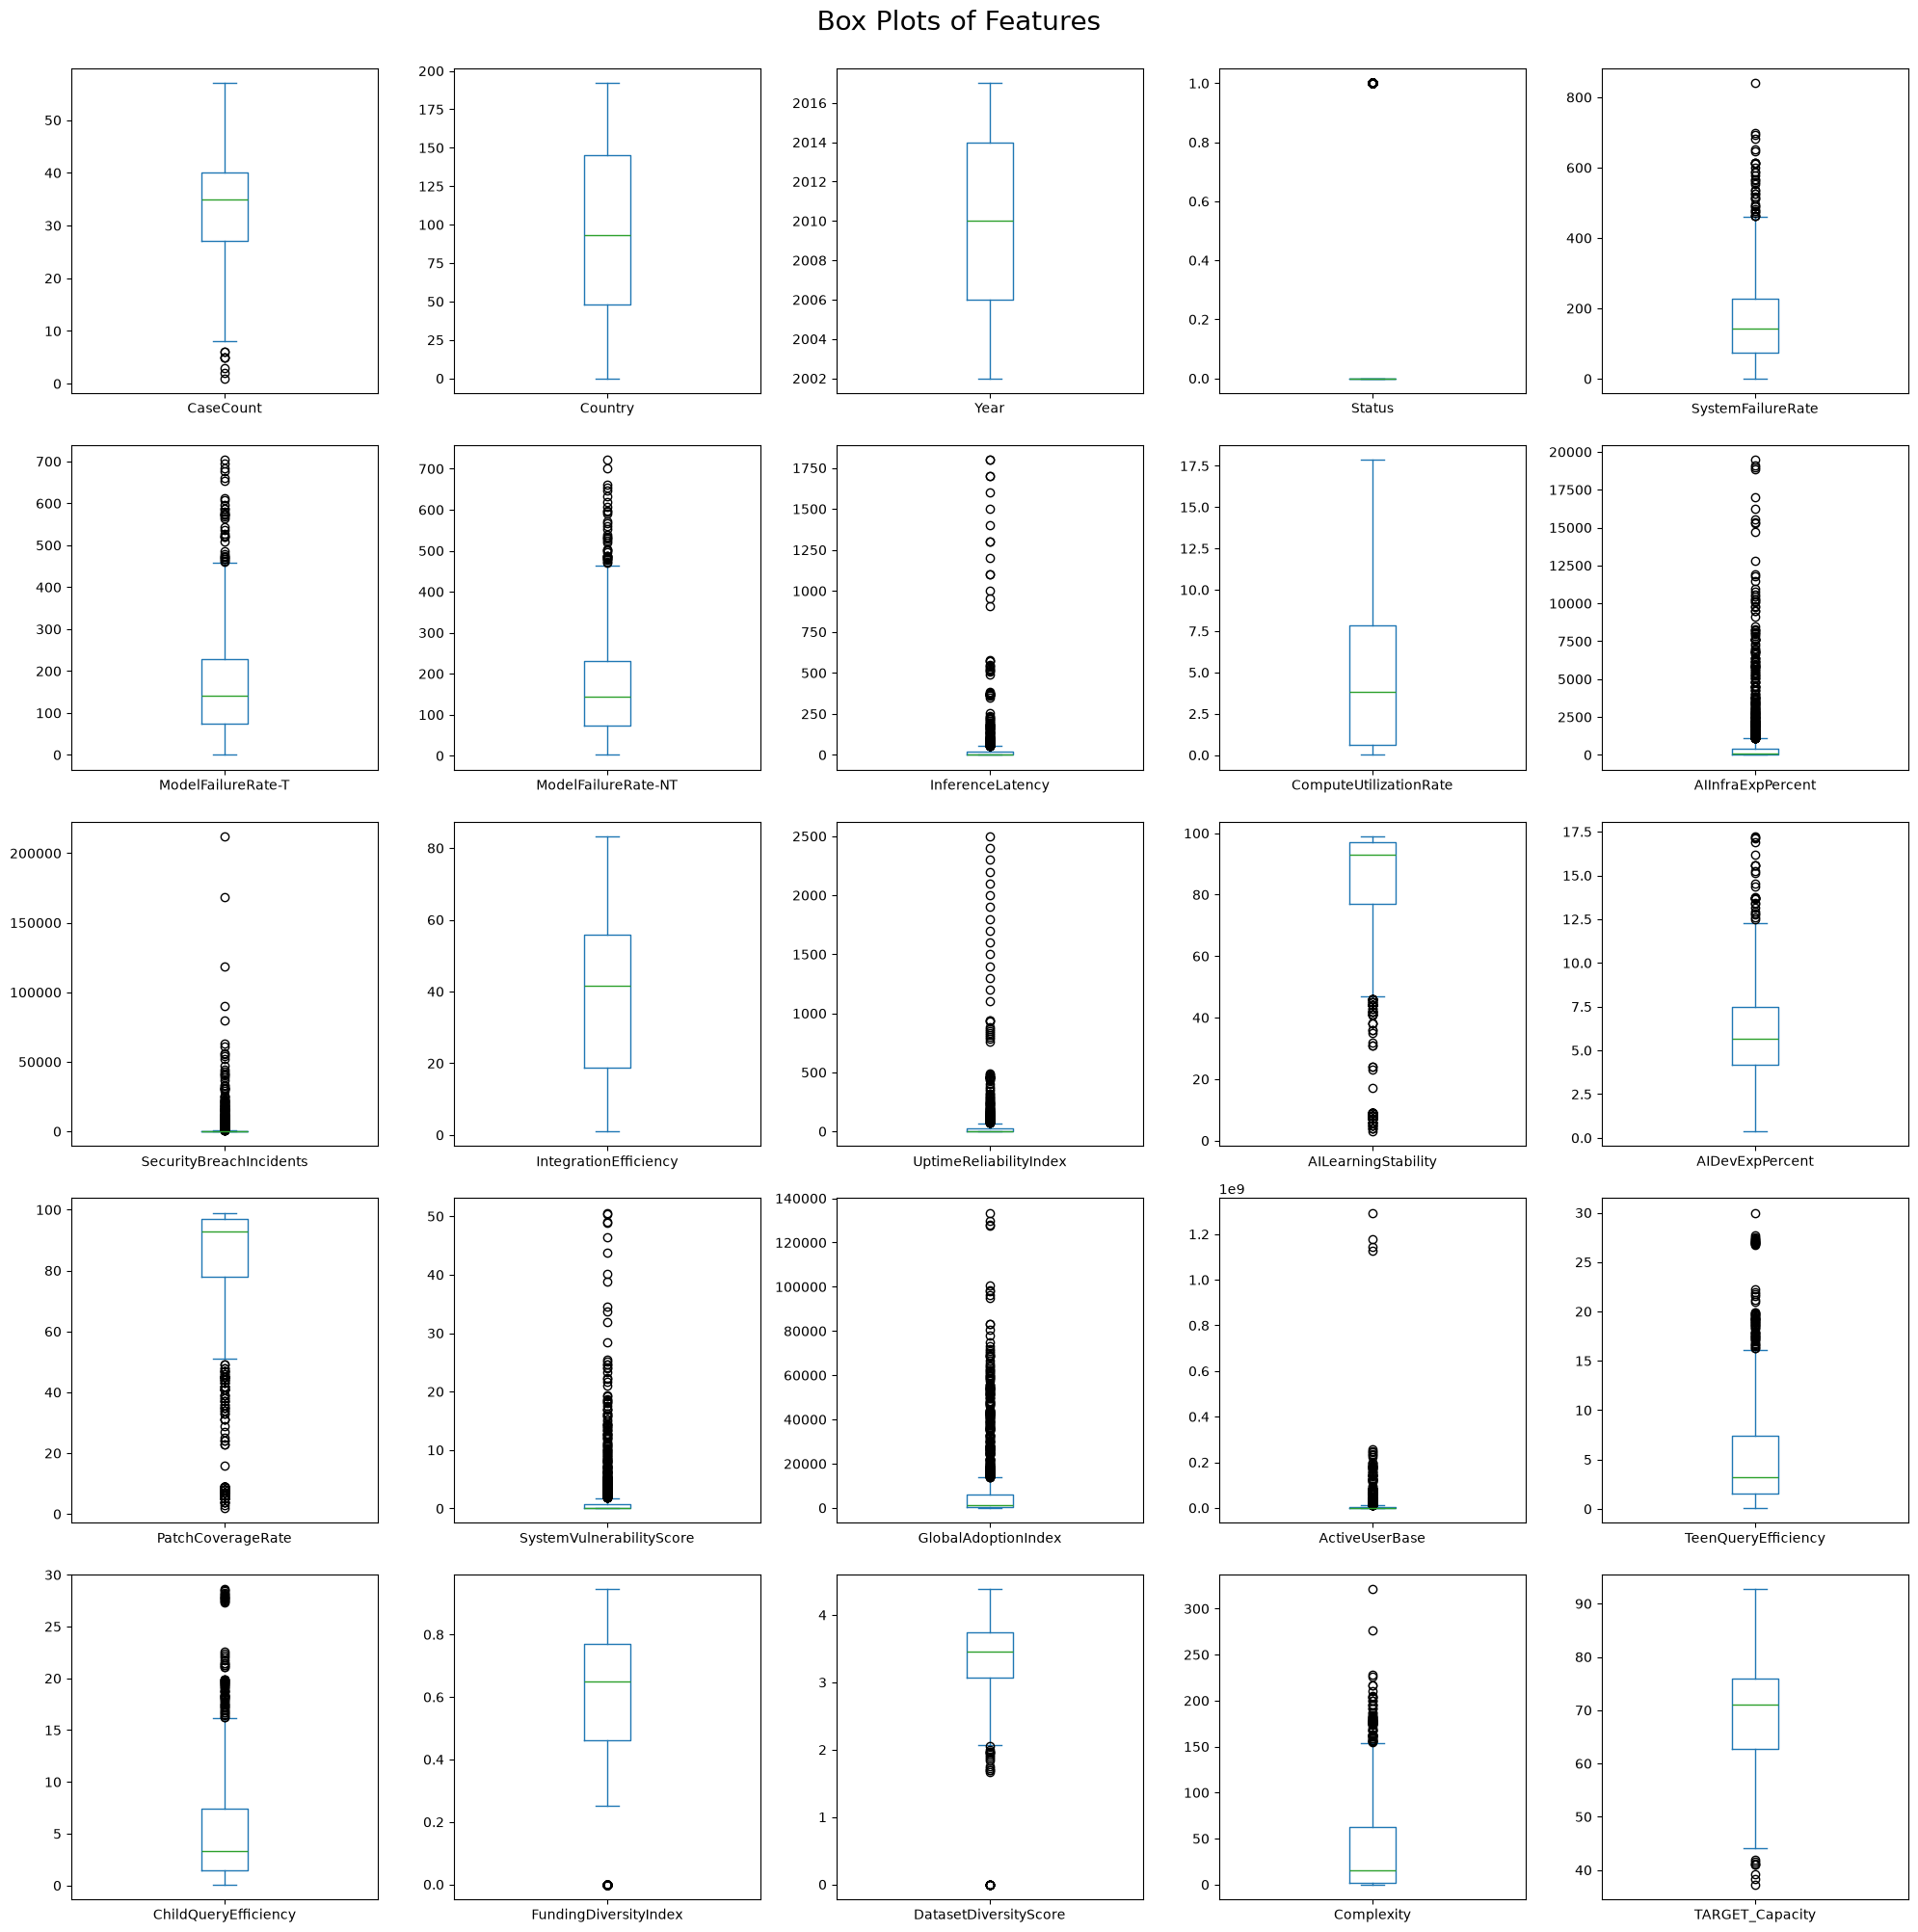

In [21]:
training_data.plot(kind='box', subplots=True, layout=(5,5), figsize=(20,20), sharex=False, sharey=False)

plt.suptitle("Box Plots of Features", y=1, fontsize=20)
plt.tight_layout()
plt.show()

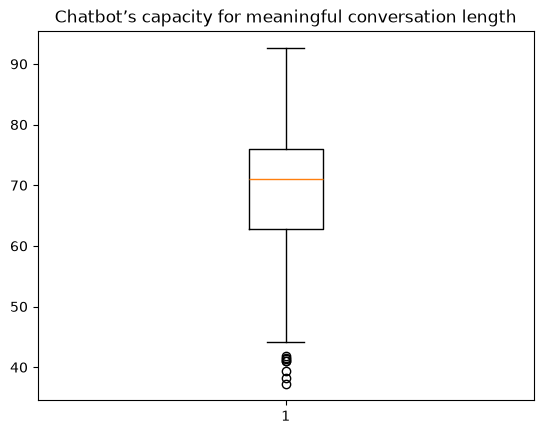

In [22]:
plt.boxplot(training_data['TARGET_Capacity'])
plt.title('Chatbot’s capacity for meaningful conversation length')
plt.show()

In [23]:
def analyze_outliers_iqr(col, df):
    """
    Analyze outliers in a column using the IQR (Tukey's) method.

    Parameters:
    col : str
        Column name to analyze
    df : pandas DataFrame
        DataFrame containing the data (defaults to global df if not provided)
    """

    # 1st quartile (25%)
    q1 = np.percentile(df[col], 25)
    # 3rd quartile (75%)
    q3 = np.percentile(df[col], 75)

    # Interquartile range (IQR)
    iqr = q3 - q1

    min_val = q1 - (iqr * 1.5)
    max_val = q3 + (iqr * 1.5)

    outliers_cnt = len(np.where((df[col] > max_val) | (df[col] < min_val))[0])
    rate = round(outliers_cnt / len(df[col]) * 100, 2)

    return outliers_cnt, rate

In [24]:
outlier_counts = []

for col in training_data.columns:
    outliers_cnt, rate = analyze_outliers_iqr(col, df=training_data)
    outlier_counts.append({
        "Feature": col,
        "Outlier Count": outliers_cnt,
        "Outlier Rate (%)": rate
    })

outlier_counts.sort(key=lambda x: x["Outlier Count"], reverse=True)
outlier_table = pd.DataFrame(outlier_counts)
outlier_table

,Feature,Outlier Count,Outlier Rate (%)
0,SecurityBreachIncidents,310,18.81
1,Status,308,18.69
2,SystemVulnerabilityScore,290,17.60
3,GlobalAdoptionIndex,242,14.68
4,AIInfraExpPercent,239,14.50
5,ActiveUserBase,221,13.41
6,UptimeReliabilityIndex,196,11.89
7,InferenceLatency,174,10.56
8,PatchCoverageRate,165,10.01
9,AILearningStability,141,8.56


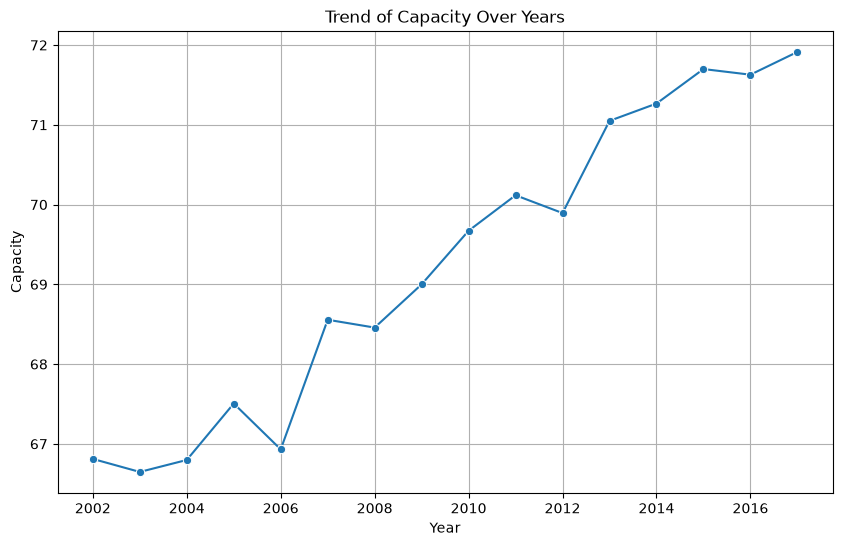

In [25]:
# Group by year and calculate mean LLM's capacity
trend_data = training_data.groupby("Year")["TARGET_Capacity"].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(data=trend_data, x="Year", y="TARGET_Capacity", marker="o")
plt.title("Trend of Capacity Over Years")
plt.ylabel("Capacity")
plt.xlabel("Year")
plt.grid(True)
plt.show()

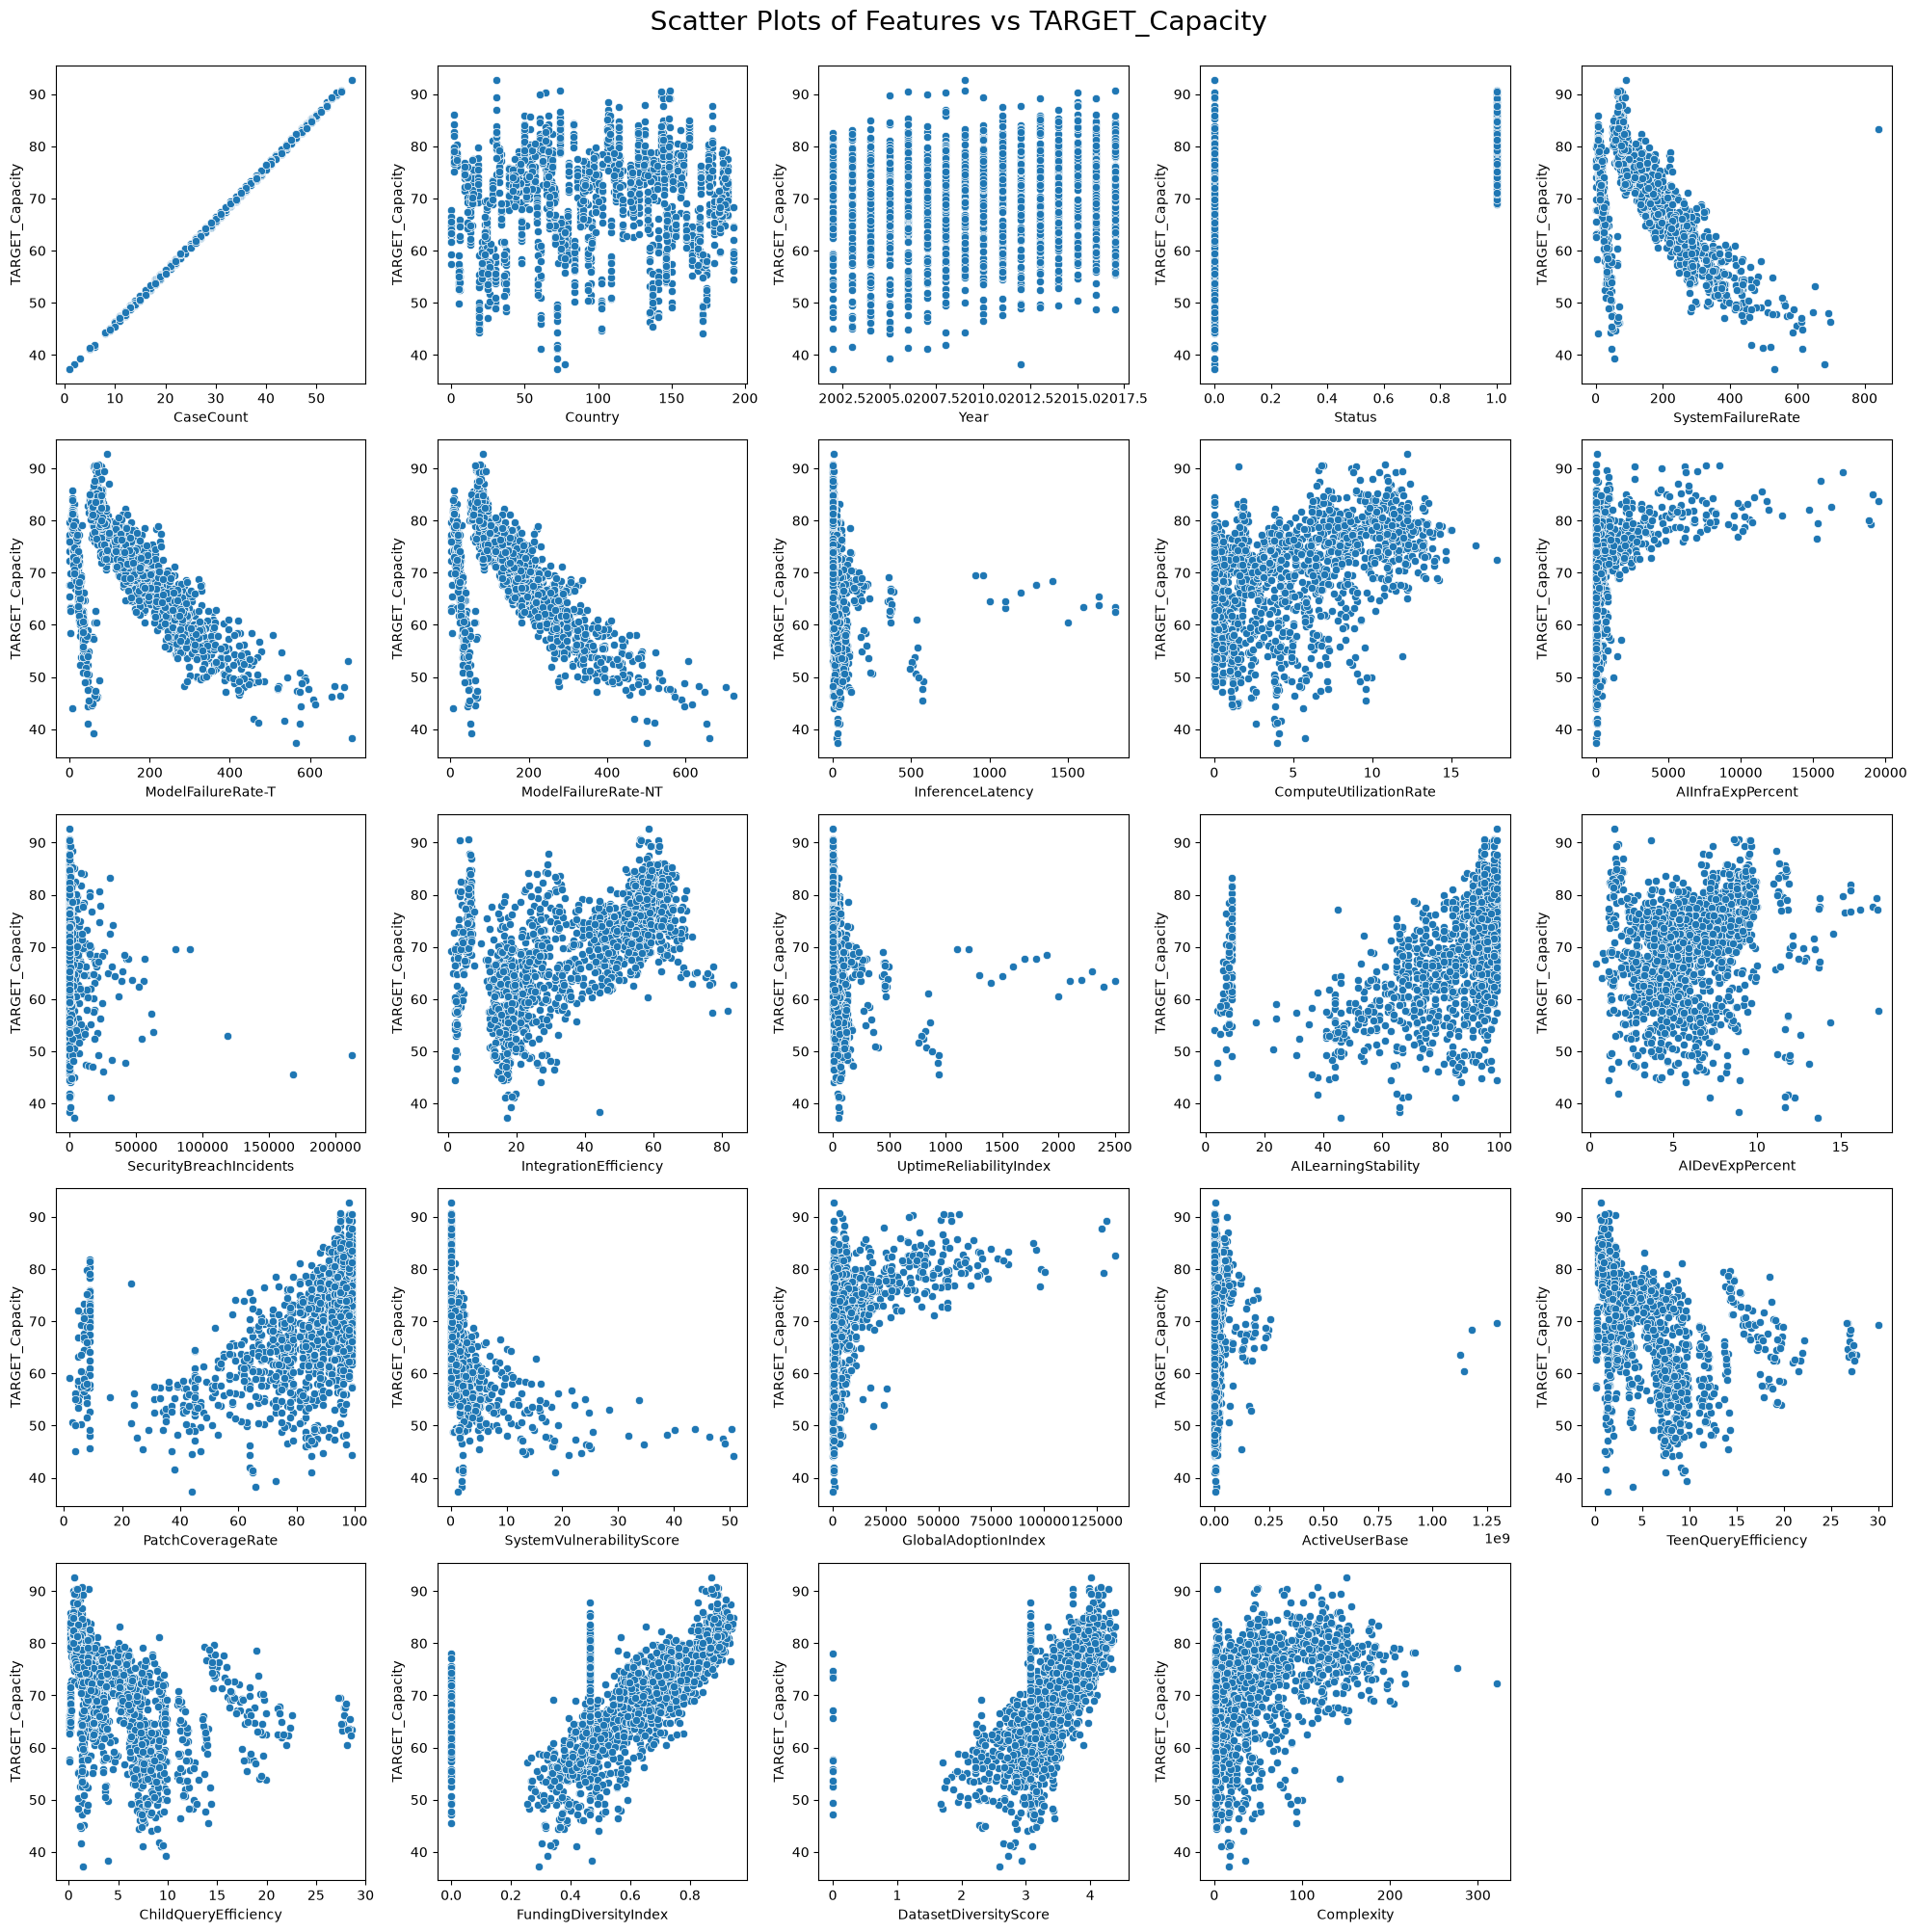

In [26]:
target = "TARGET_Capacity"
features = [col for col in training_data.select_dtypes(include="number").columns if col != target]

n = len(features)
cols = 5
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.scatterplot(data=training_data, x=feature, y=target, ax=axes[i])

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Scatter Plots of Features vs TARGET_Capacity", y=1, fontsize=20)
plt.tight_layout()
plt.show()

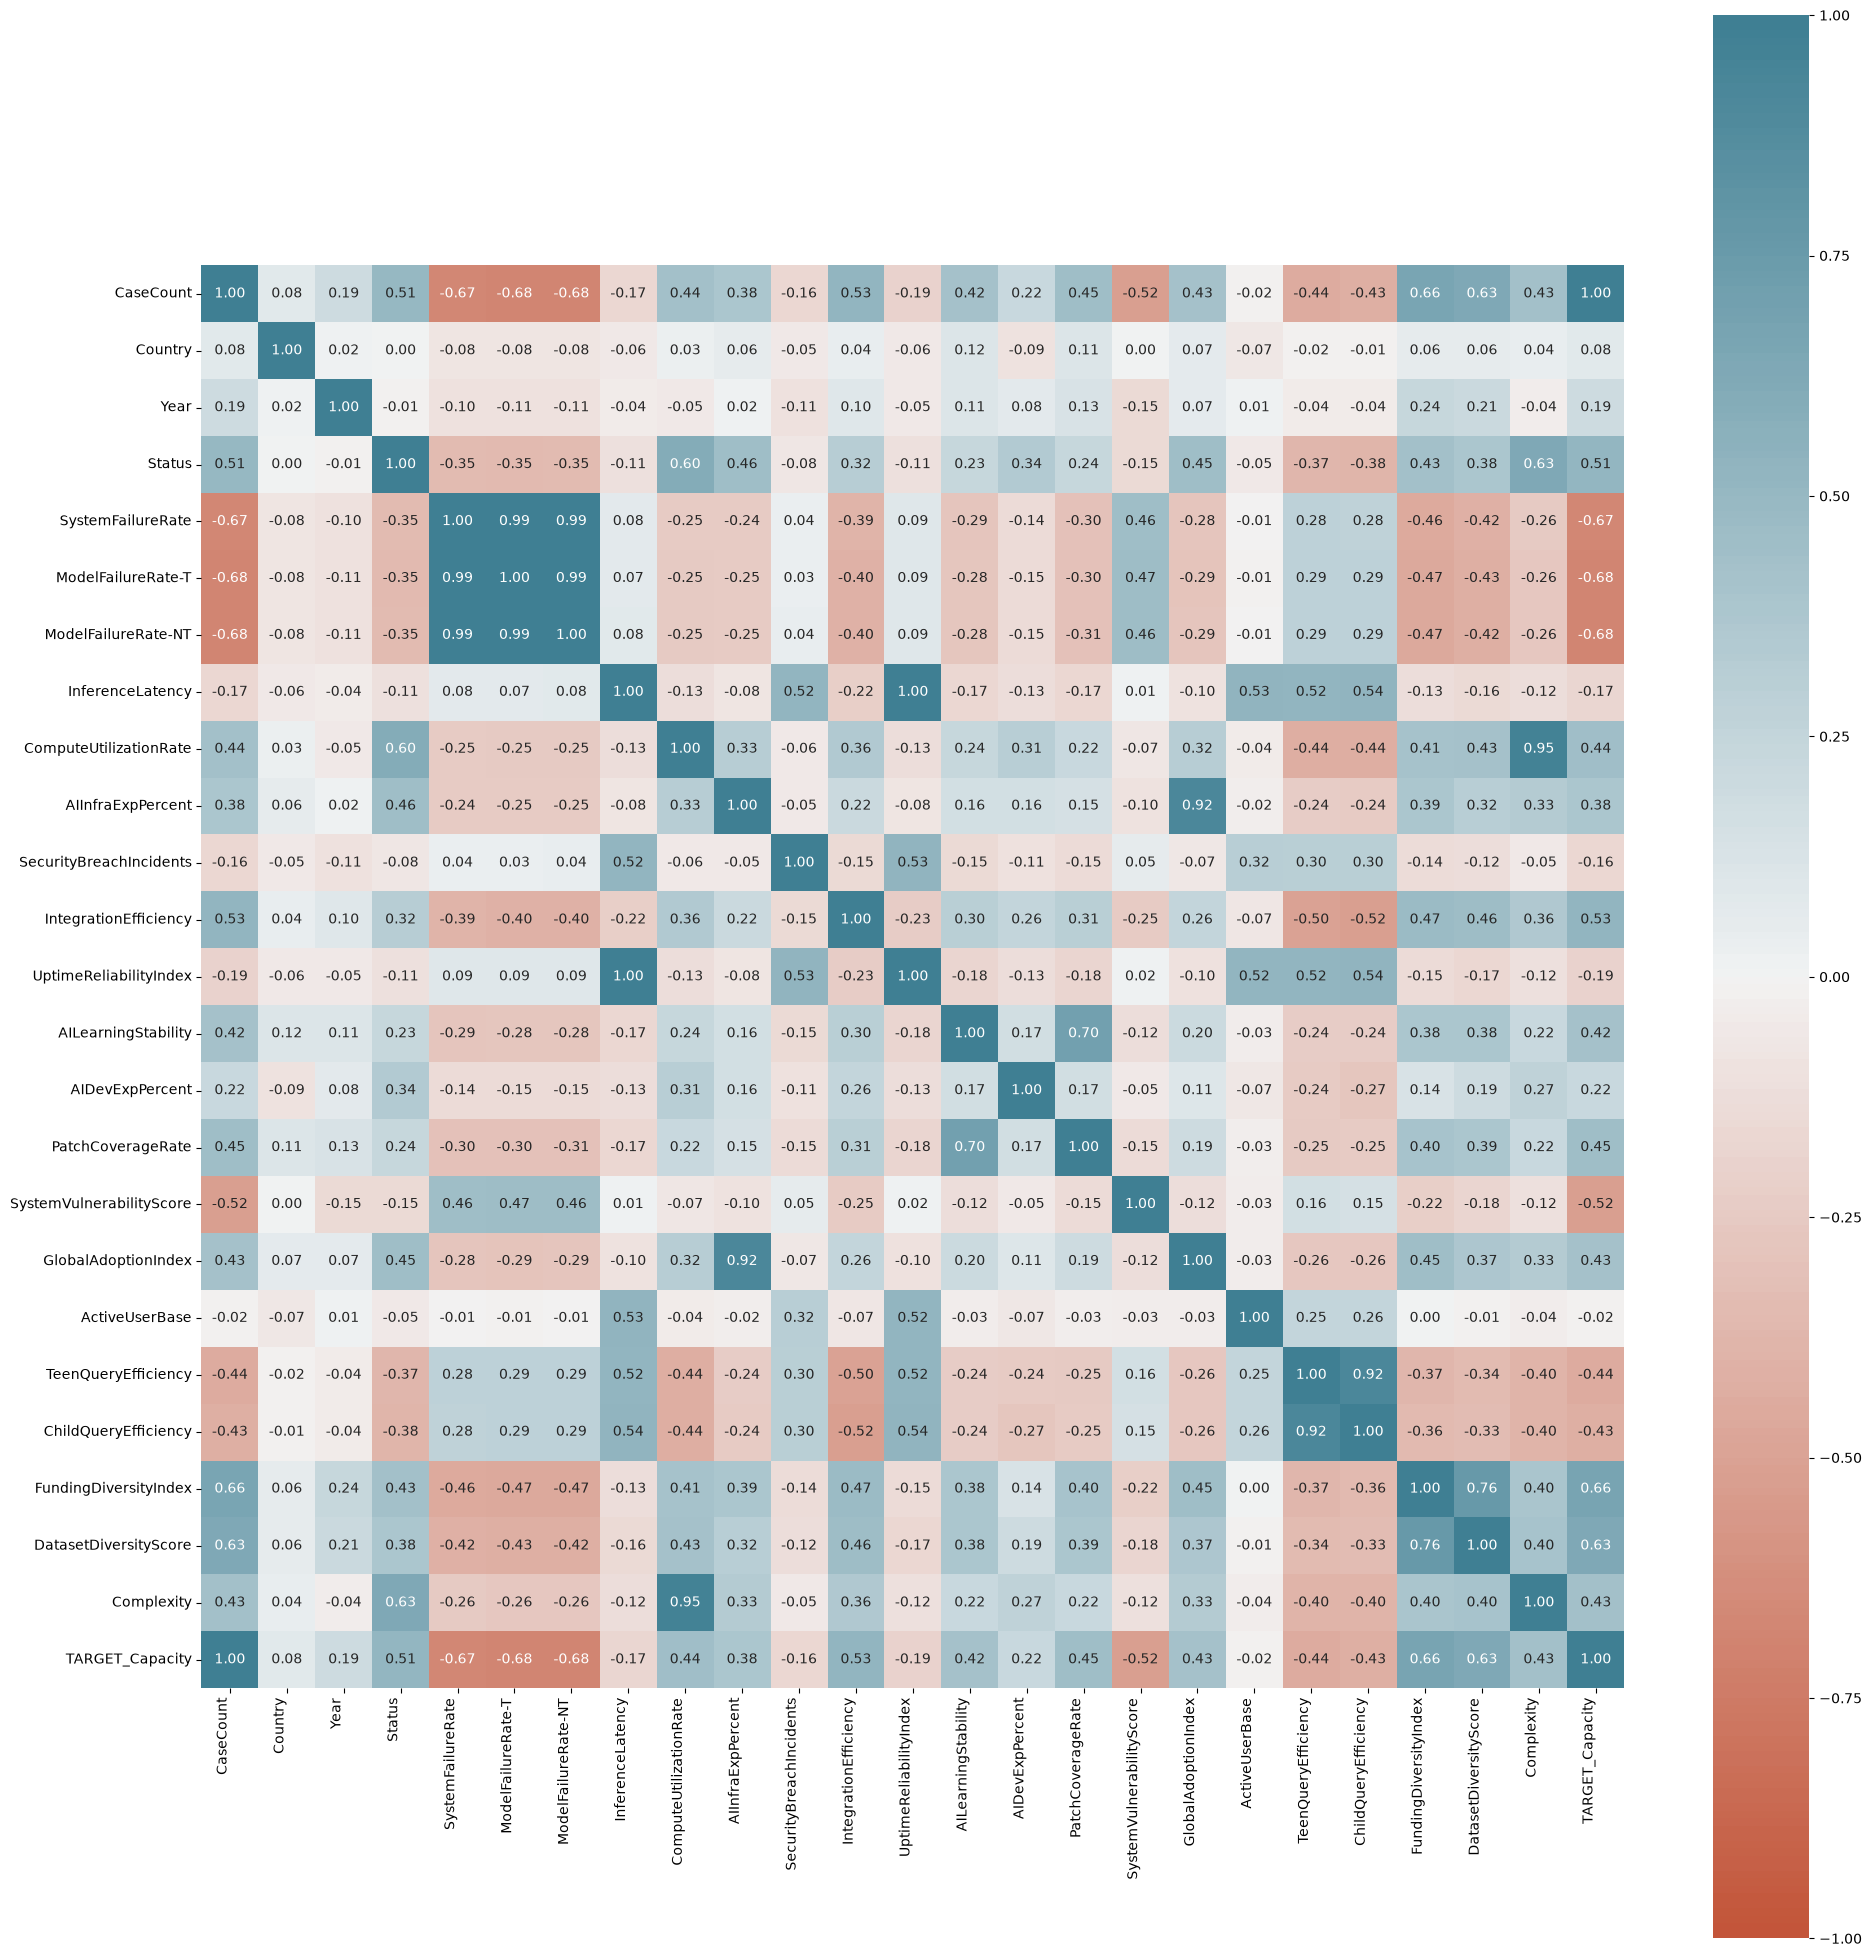

In [27]:
f, ax = plt.subplots(figsize=(20, 20))
corr = training_data.corr()
ax = sns.heatmap(
    corr,
    vmin=-1, vmax=1, center=0,
    cmap=sns.diverging_palette(20, 220, n=200),
    square=True,
    annot=True,
    fmt=".2f",
)
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=90,
    horizontalalignment='right'
)

plt.tight_layout()
plt.show()

Drop the 'CaseCount' column as it has high correlation with 'TARGET_Capacity' and may lead to data leakage in predictive modeling

In [28]:
leakage_cols = ["CaseCount"]

Drop the 'Country' and 'ActiveUserBase' columns as they have low correlation with the target variable (|r| < 0.1)

In [29]:
low_corr_cols = ["Country", "ActiveUserBase"]

In [30]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

vif_input = X_train.drop(columns=leakage_cols + low_corr_cols, errors="ignore")
X = vif_input.select_dtypes(include=[np.number]).copy()

X_const = add_constant(X)

vif_data = pd.DataFrame({
    "Feature": X_const.columns,
    "VIF": [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]
})

vif_data = vif_data[vif_data["Feature"] != "const"].sort_values("VIF", ascending=False)
vif_data

,Feature,VIF
11,UptimeReliabilityIndex,221.084103
6,InferenceLatency,217.640921
4,ModelFailureRate-T,71.601937
5,ModelFailureRate-NT,71.169924
3,SystemFailureRate,43.297288
7,ComputeUtilizationRate,12.951842
21,Complexity,12.694386
16,GlobalAdoptionIndex,7.714477
8,AIInfraExpPercent,7.341321
18,ChildQueryEfficiency,6.816075


Derived from the VIF analysis, we can see that some features have high multicollinearity. To address this, we will drop the following columns: 'ModelFailureRate-T', 'ModelFailureRate-NT', 'InferenceLatency', and 'Complexity'.

In [31]:
from feature_engine.selection import DropFeatures

vif_cols_to_drop = ["ModelFailureRate-T", "ModelFailureRate-NT", "InferenceLatency", "Complexity"]
columns_to_drop = leakage_cols + low_corr_cols + vif_cols_to_drop

feature_dropper = DropFeatures(features_to_drop=columns_to_drop)

In [32]:
from feature_engine.creation import MathFeatures

query_efficiency_cols = ["TeenQueryEfficiency", "ChildQueryEfficiency"]

underage_query_efficiency_creator = MathFeatures(
    variables=query_efficiency_cols,
    func="mean",
    new_variables_names=["UnderageQueryEfficiency"],
    drop_original=True,
)

In [33]:
from feature_engine.outliers import ArbitraryOutlierCapper

capper = ArbitraryOutlierCapper(
    max_capping_dict={
        'SecurityBreachIncidents': 50000,
        'GlobalAdoptionIndex': 100000,
        'UnderageQueryEfficiency': 20
    }
)

In [34]:
from feature_engine.outliers import Winsorizer

winsor_cols = ['SystemFailureRate', 'FundingDiversityIndex', 'DatasetDiversityScore']

winsorizer = Winsorizer(capping_method='iqr', tail='both', fold=1.5, variables=winsor_cols)

In [35]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, PowerTransformer

log_cols = [
    "AIInfraExpPercent",
    "SecurityBreachIncidents",
    "UptimeReliabilityIndex",
    "GlobalAdoptionIndex",
    "UnderageQueryEfficiency",
]

yeo_cols = [
    "SystemVulnerabilityScore",
    "AILearningStability",
    "PatchCoverageRate",
]

transformer = ColumnTransformer(
    transformers=[
        ("log1p", FunctionTransformer(np.log1p, validate=False), log_cols),
        ("yeojohnson", PowerTransformer(method="yeo-johnson", standardize=False), yeo_cols),
    ],
    remainder="passthrough",
    verbose_feature_names_out=False
)

In [36]:
from feature_engine.wrappers import SklearnTransformerWrapper
from sklearn.preprocessing import MinMaxScaler

min_max_cols = [
    "AILearningStability",
    "PatchCoverageRate",
]

min_max_scaler = SklearnTransformerWrapper(
    transformer=MinMaxScaler(),
    variables=min_max_cols,
)

In [37]:
from pathlib import Path
from sklearn.pipeline import Pipeline
import joblib

preprocess_pipeline = Pipeline(
    steps=[
        ("feature_dropper", feature_dropper),
        ("underage_query_efficiency_creator", underage_query_efficiency_creator),
        ("arbitrary_capper", capper),
        ("winsorizer", winsorizer),
        ("column_transformer", transformer),
        ("min_max_scaler", min_max_scaler)
    ],
).set_output(transform="pandas")

Path("pipelines").mkdir(exist_ok=True)
joblib.dump(preprocess_pipeline, "pipelines/preprocess_pipeline.pkl")

['pipelines/preprocess_pipeline.pkl']

In [38]:
X_train_transformed = preprocess_pipeline.fit_transform(X_train)

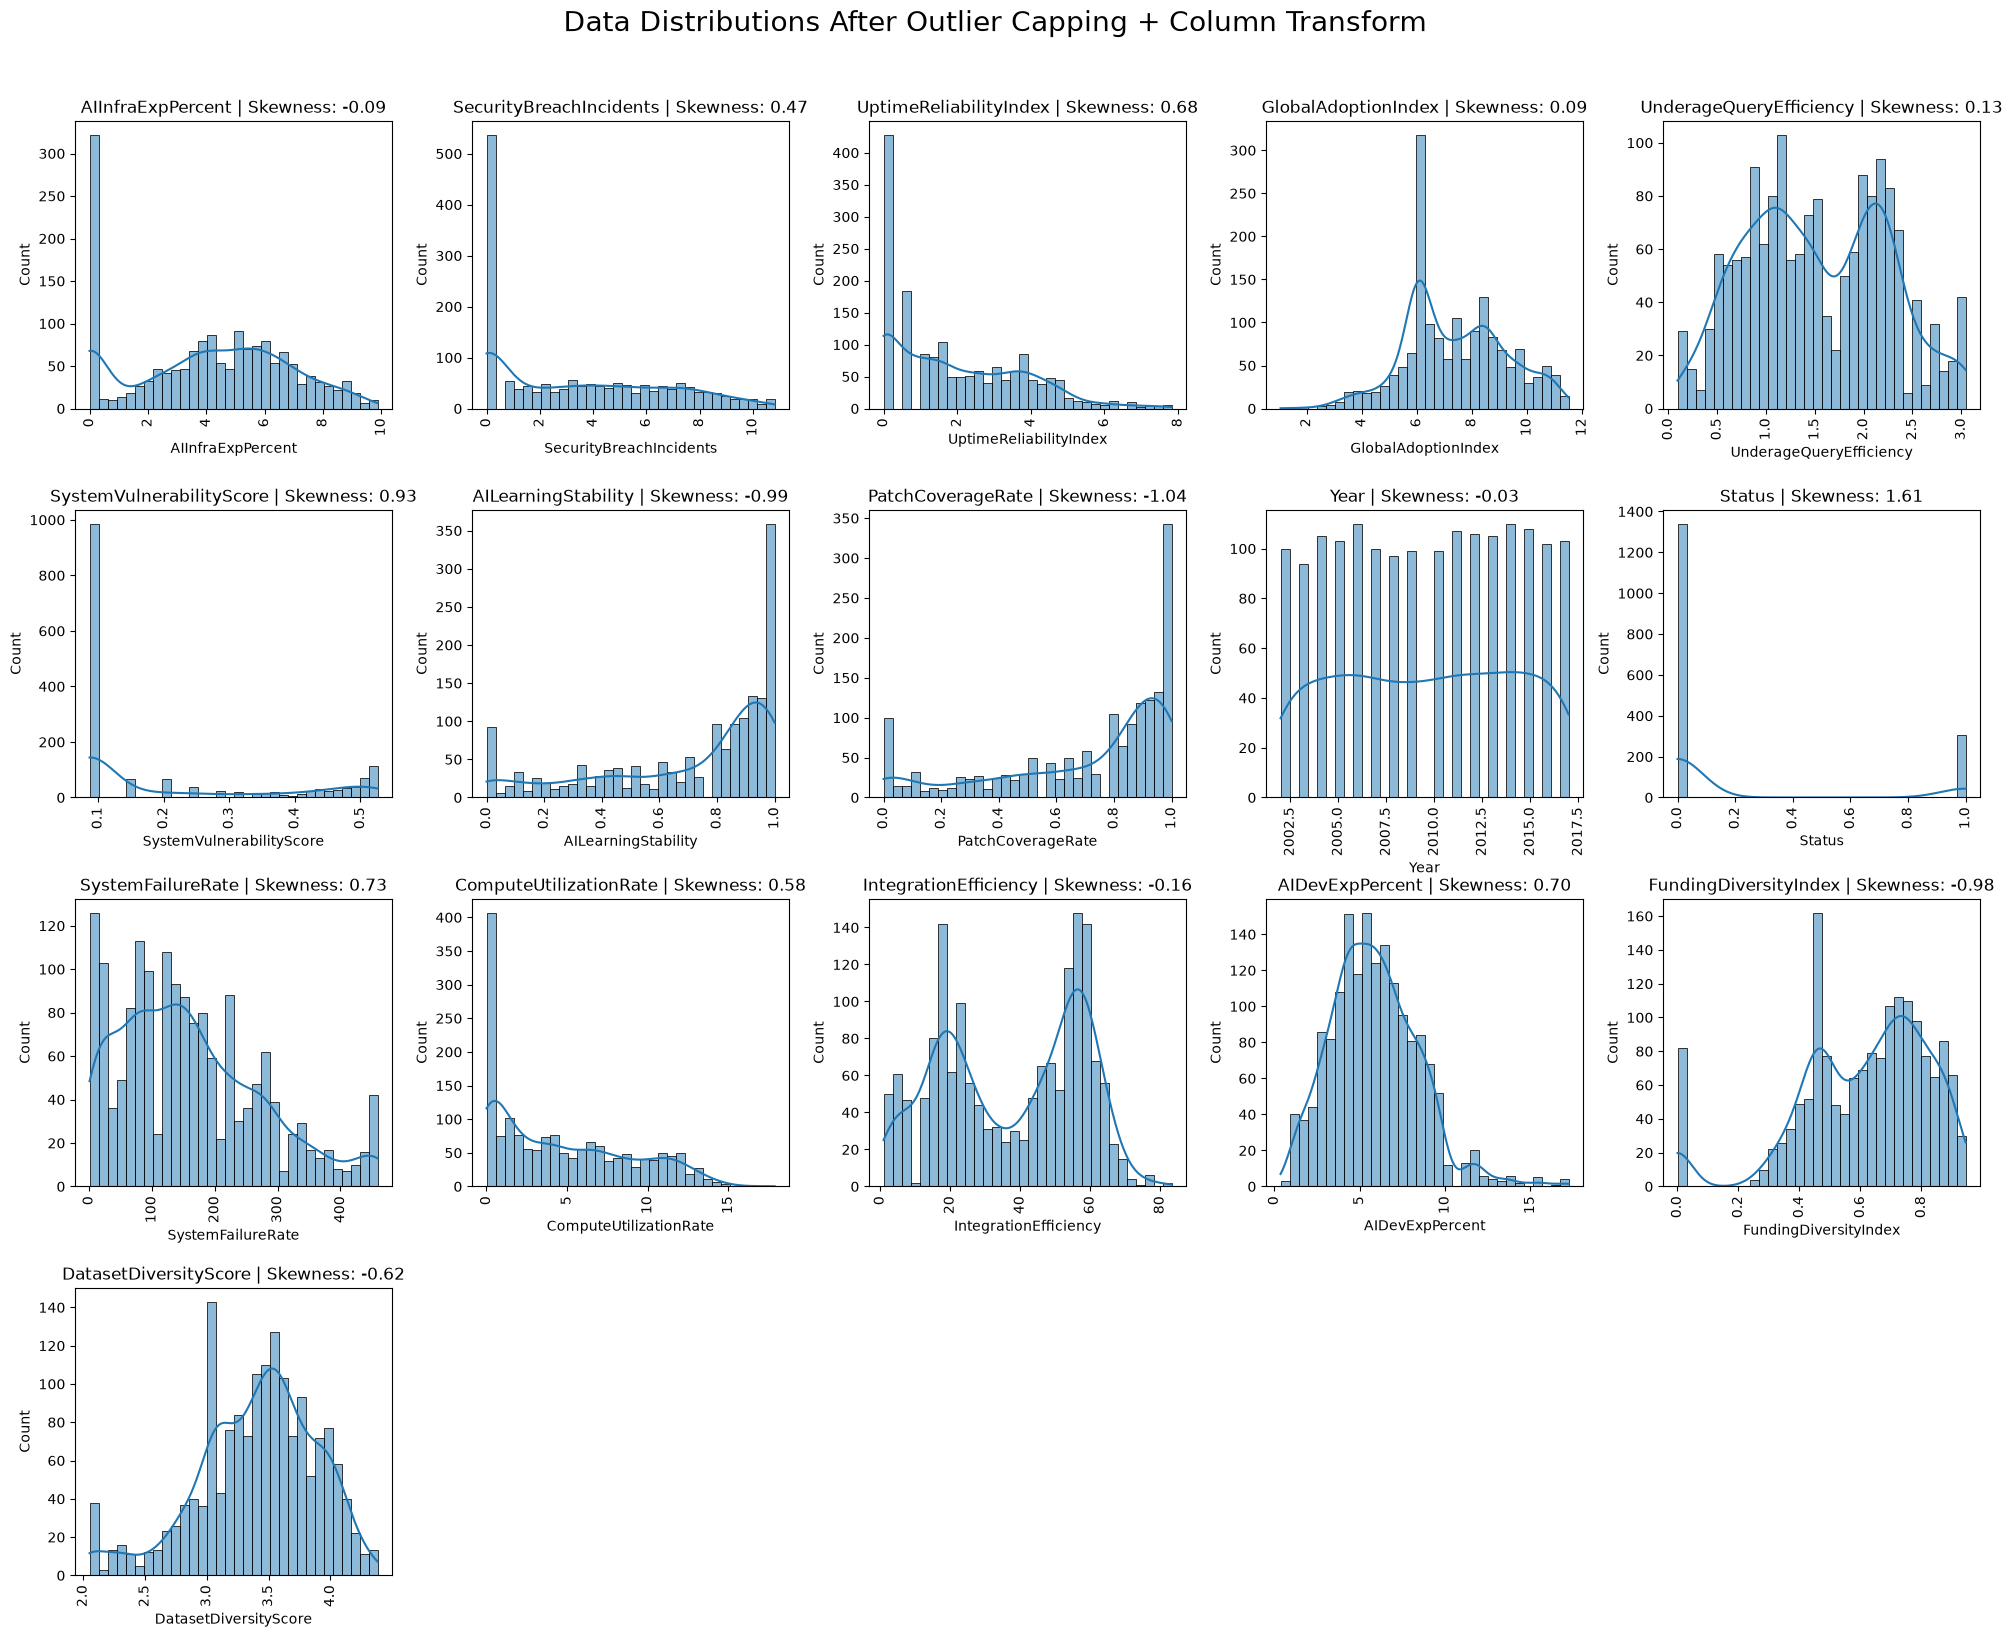

In [39]:
plot_cols = X_train_transformed.select_dtypes(include=np.number).columns
n = len(plot_cols)
cols = 5
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(plot_cols):
    sns.histplot(X_train_transformed[col], kde=True, bins=32, ax=axes[i])
    axes[i].set_title(f"{col} | Skewness: {X_train_transformed[col].skew():.2f}")
    axes[i].tick_params(axis="x", rotation=90)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Data Distributions After Outlier Capping + Column Transform", y=1.02, fontsize=20)
plt.tight_layout()
plt.show()

### Train & save the models on the training set

There are several models that we can train on the training set:
- Linear Regression (degree 1)
- Elastic Net (degree 2)
- Elastic Net (degree 3)
- SVR
- Random Forest
- XGBoost
- CatBoost

In [64]:
from sklearn.model_selection import RandomizedSearchCV, cross_validate

RANDOM_STATE = 42
N_ITER = 30

def train_model(config, X_train, y_train, cv):
    model_name = config["display_name"]
    estimator = config["estimator_factory"]()

    print(f"\n{'=' * 80}")
    print(f"Training: {model_name}")

    if not config.get("random_search", True):
        cv_results = cross_validate(
            estimator,
            X_train,
            y_train,
            cv=cv,
            scoring={
                "r2": "r2",
                "rmse": "neg_root_mean_squared_error",
                "mae": "neg_mean_absolute_error",
            },
            n_jobs=-1,
        )

        r2 = cv_results["test_r2"]
        rmse = -cv_results["test_rmse"]
        mae = -cv_results["test_mae"]

        print(f"R2 values per fold: {r2}")
        print(f"Mean R2 value: {np.mean(r2):.4f}")
        print(f"RMSE values per fold: {rmse}")
        print(f"Mean RMSE value: {np.mean(rmse):.4f}")
        print(f"MAE values per fold: {mae}")
        print(f"Mean MAE value: {np.mean(mae):.4f}")

        estimator.fit(X_train, y_train)
        return estimator

    search = RandomizedSearchCV(
        estimator=estimator,
        param_distributions=config["param_distributions"],
        n_iter=config.get("n_iter", N_ITER),
        cv=cv,
        scoring={
            "r2": "r2",
            "rmse": "neg_root_mean_squared_error",
            "mae": "neg_mean_absolute_error",
        },
        refit="r2",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=1,
    )
    search.fit(X_train, y_train)

    print(f"Best CV R2: {search.cv_results_['mean_test_r2'][search.best_index_]:.4f}")
    print(f"CV RMSE: {-search.cv_results_['mean_test_rmse'][search.best_index_]:.4f}")
    print(f"CV MAE: {-search.cv_results_['mean_test_mae'][search.best_index_]:.4f}")
    print("Best parameters:")
    for param_name, param_value in search.best_params_.items():
        print(f"  {param_name}: {param_value}")

    return search


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

RANDOM_STATE = 42
N_ITER = 30

kf = KFold(n_splits=5, random_state=RANDOM_STATE, shuffle=True)

tree_model_drop_cols = ["CaseCount"]
X_train_tree = X_train.drop(columns=tree_model_drop_cols, errors="ignore")
X_test_tree = X_test.drop(columns=tree_model_drop_cols, errors="ignore")

model_configs = {
    "linear_regression": {
        "display_name": "Linear Regression",
        "estimator_factory": lambda: Pipeline(
            steps=[
                ("preprocess", preprocess_pipeline),
                ("model", LinearRegression()),
            ]
        ),
        "random_search": False,
    },
    "elastic_net_degree_2": {
        "display_name": "Elastic Net (degree = 2)",
        "estimator_factory": lambda: Pipeline(
            steps=[
                ("preprocess", preprocess_pipeline),
                ("polynomial_features", PolynomialFeatures(degree=2, include_bias=False)),
                ("scaler", StandardScaler()),
                ("model", ElasticNet(max_iter=20000, random_state=RANDOM_STATE)),
            ]
        ),
        "param_distributions": {
            "model__alpha": np.logspace(-4, 2, 100),
            "model__l1_ratio": np.linspace(0.05, 0.95, 19),
        },
        "n_iter": N_ITER,
    },
    "elastic_net_degree_3": {
        "display_name": "Elastic Net (degree = 3)",
        "estimator_factory": lambda: Pipeline(
            steps=[
                ("preprocess", preprocess_pipeline),
                ("polynomial_features", PolynomialFeatures(degree=3, include_bias=False)),
                ("scaler", StandardScaler()),
                ("model", ElasticNet(max_iter=20000, random_state=RANDOM_STATE)),
            ]
        ),
        "param_distributions": {
            "model__alpha": np.logspace(-4, 2, 100),
            "model__l1_ratio": np.linspace(0.05, 0.95, 19),
        },
        "n_iter": N_ITER,
    },
    "svr": {
        "display_name": "SVR",
        "estimator_factory": lambda: Pipeline(
            steps=[
                ("preprocess", preprocess_pipeline),
                ("scaler", StandardScaler()),
                ("model", SVR()),
            ]
        ),
        "param_distributions": {
            "model__C": np.logspace(-1, 3, 50),
            "model__epsilon": np.logspace(-3, 1, 50),
            "model__gamma": ["scale", "auto"],
            "model__kernel": ["rbf", "linear", "poly"],
        },
        "n_iter": N_ITER,
    },
    "random_forest": {
        "display_name": "Random Forest",
        "estimator_factory": lambda: RandomForestRegressor(
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        "param_distributions": {
            "n_estimators": [200, 400, 600, 800],
            "max_depth": [None, 5, 10, 20, 30],
            "min_samples_split": [2, 5, 10],
            "min_samples_leaf": [1, 2, 4],
            "max_features": ["sqrt", "log2", 0.5, 0.8, 1.0],
            "bootstrap": [True, False],
        },
        "n_iter": N_ITER,
    },
    "xgboost": {
        "display_name": "XGBoost",
        "estimator_factory": lambda: XGBRegressor(
            objective="reg:squarederror",
            tree_method="hist",
            eval_metric="rmse",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        "param_distributions": {
            "n_estimators": [200, 400, 600, 800],
            "max_depth": [2, 3, 4, 5, 6, 8],
            "learning_rate": np.logspace(-3, -0.3, 50),
            "subsample": np.linspace(0.6, 1.0, 9),
            "colsample_bytree": np.linspace(0.6, 1.0, 9),
            "reg_alpha": np.logspace(-4, 1, 30),
            "reg_lambda": np.logspace(-2, 2, 30),
        },
        "n_iter": N_ITER,
    },
    "catboost": {
        "display_name": "CatBoost",
        "estimator_factory": lambda: CatBoostRegressor(
            loss_function="RMSE",
            random_seed=RANDOM_STATE,
            verbose=False,
            allow_writing_files=False,
            thread_count=-1,
        ),
        "param_distributions": {
            "iterations": [200, 400, 600, 800],
            "depth": [2, 3, 4, 5, 6, 8],
            "learning_rate": np.logspace(-3, -0.3, 50),
            "l2_leaf_reg": np.logspace(-2, 2, 30),
            "random_strength": np.linspace(0.0, 2.0, 21),
        },
        "n_iter": N_ITER,
    },
}


In [ ]:
from pathlib import Path
import joblib

linear_regression_model = train_model(
    model_configs["linear_regression"],
    X_train,
    y_train,
    cv=kf,
)

Path.mkdir("models", exist_ok=True)
joblib.dump(linear_regression_model, "models/linear_regression.pkl")
print("Saved linear_regression to models/linear_regression.pkl")


Training: Linear Regression
R2 values per fold: [0.80545187 0.78592121 0.75494957 0.74474085 0.77949531]
Mean R2 value: 0.7741
RMSE values per fold: [4.04654935 4.30413232 4.46848034 4.92810184 4.84942424]
Mean RMSE value: 4.5193
MAE values per fold: [3.11560328 3.30878266 3.39516974 3.68989378 3.59070193]
Mean MAE value: 3.4200


In [ ]:
from pathlib import Path
import joblib

elastic_net_degree_2_model = train_model(
    model_configs["elastic_net_degree_2"],
    X_train,
    y_train,
    cv=kf,
)

Path.mkdir("models", exist_ok=True)
joblib.dump(elastic_net_degree_2_model, "models/elastic_net_degree_2.pkl")
print("Saved elastic_net_degree_2 to models/elastic_net_degree_2.pkl")



Training: Elastic Net (degree = 2)
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best CV R2: 0.8594
CV RMSE: 3.5624
CV MAE: 2.6689
Best parameters:
  model__l1_ratio: 0.7
  model__alpha: 0.004328761281083062


In [ ]:
from pathlib import Path
import joblib

elastic_net_degree_3_model = train_model(
    model_configs["elastic_net_degree_3"],
    X_train,
    y_train,
    cv=kf,
)

Path("models").mkdir(exist_ok=True)
joblib.dump(elastic_net_degree_3_model, "models/elastic_net_degree_3.pkl")
print("Saved elastic_net_degree_3 to models/elastic_net_degree_3.pkl")

In [114]:
from pathlib import Path
import joblib

svr_model = train_model(
    model_configs["svr"],
    X_train,
    y_train,
    cv=kf,
)

Path("models").mkdir(exist_ok=True)
joblib.dump(svr_model, "models/svr.pkl")
print("Saved svr to models/svr.pkl")


Training: SVR
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best CV R2: 0.8712
CV RMSE: 3.4144
CV MAE: 2.5692
Best parameters:
  model__kernel: rbf
  model__gamma: scale
  model__epsilon: 1.0481131341546852
  model__C: 15.998587196060573
Saved svr to models/svr.pkl


In [ ]:
from pathlib import Path
import joblib

random_forest_model = train_model(
    model_configs["random_forest"],
    X_train_tree,
    y_train,
    cv=kf,
)

Path("models").mkdir(exist_ok=True)
joblib.dump(random_forest_model, "models/random_forest.pkl")
print("Saved random_forest to models/random_forest.pkl")

In [ ]:
from pathlib import Path
import joblib

xgboost_model = train_model(
    model_configs["xgboost"],
    X_train_tree,
    y_train,
    cv=kf
)

Path("models").mkdir(exist_ok=True)
joblib.dump(xgboost_model, "models/xgboost.pkl")
print("Saved xgboost to models/xgboost.pkl")

In [ ]:
from pathlib import Path
import joblib

catboost_model = train_model(
    model_configs["catboost"],
    X_train_tree,
    y_train,
    cv=kf,
)

Path("models").mkdir(exist_ok=True)
joblib.dump(catboost_model, "models/catboost.pkl")
print("Saved catboost to models/catboost.pkl")

### Evaluate models on the holdout test set


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)

    result = {
        "model": name,
        "y_pred": y_pred,
        "r2": r2_score(y_test, y_pred),
        "rmse": np.sqrt(mean_squared_error(y_test, y_pred)),
        "mae": mean_absolute_error(y_test, y_pred),
    }

    print(f"\n{name} holdout performance")
    print(f"Test R2: {result['r2']:.4f}")
    print(f"Test RMSE: {result['rmse']:.4f}")
    print(f"Test MAE: {result['mae']:.4f}")

    return result

In [91]:
linear_regression_result = evaluate_model(
    "Linear Regression",
    linear_regression_model,
    X_test,
    y_test,
)

test_comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": linear_regression_result["y_pred"],
})
test_comparison["Residual"] = test_comparison["Actual"] - test_comparison["Predicted"]

print("\nTest Comparison (Actual vs Predicted):")
test_comparison.head(10)


Linear Regression holdout performance
Test R2: 0.7816
Test RMSE: 4.3111
Test MAE: 3.3302

Test Comparison (Actual vs Predicted):


,Actual,Predicted,Residual
1310,50.6,51.741073,-1.141073
600,68.0,58.343337,9.656663
1330,59.3,73.479154,-14.179154
1077,73.3,73.926686,-0.626686
29,74.9,74.696446,0.203554
1068,73.3,79.872364,-6.572364
721,78.5,82.375177,-3.875177
462,78.6,78.364267,0.235733
1658,81.7,81.828622,-0.128622
766,78.9,70.112943,8.787057


In [93]:
elastic_net_degree_2_result = evaluate_model(
    "Elastic Net (degree = 2)",
    elastic_net_degree_2_model,
    X_test,
    y_test,
)

test_comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": elastic_net_degree_2_result["y_pred"],
})
test_comparison["Residual"] = test_comparison["Actual"] - test_comparison["Predicted"]

print("\nTest Comparison (Actual vs Predicted):")
test_comparison.head(10)


Elastic Net (degree = 2) holdout performance
Test R2: 0.8741
Test RMSE: 3.2739
Test MAE: 2.4296

Test Comparison (Actual vs Predicted):


,Actual,Predicted,Residual
1310,50.6,49.915261,0.684739
600,68.0,59.188639,8.811361
1330,59.3,66.227170,-6.927170
1077,73.3,75.626346,-2.326346
29,74.9,73.444031,1.455969
1068,73.3,75.254099,-1.954099
721,78.5,82.543836,-4.043836
462,78.6,78.541059,0.058941
1658,81.7,80.946908,0.753092
766,78.9,74.569304,4.330696


In [ ]:
elastic_net_degree_3_result = evaluate_model(
    "Elastic Net (degree = 3)",
    elastic_net_degree_3_model,
    X_test,
    y_test,
)

test_comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": elastic_net_degree_3_result["y_pred"],
})
test_comparison["Residual"] = test_comparison["Actual"] - test_comparison["Predicted"]

print("\nTest Comparison (Actual vs Predicted):")
test_comparison.head(10)

In [115]:
svr_result = evaluate_model(
    "SVR",
    svr_model,
    X_test,
    y_test,
)

test_comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": svr_result["y_pred"],
})
test_comparison["Residual"] = test_comparison["Actual"] - test_comparison["Predicted"]

print("\nTest Comparison (Actual vs Predicted):")
test_comparison.head(10)


SVR holdout performance
Test R2: 0.8870
Test RMSE: 3.1016
Test MAE: 2.3151

Test Comparison (Actual vs Predicted):


,Actual,Predicted,Residual
1310,50.6,52.207168,-1.607168
600,68.0,58.352322,9.647678
1330,59.3,61.589934,-2.289934
1077,73.3,76.321966,-3.021966
29,74.9,73.568212,1.331788
1068,73.3,73.958210,-0.658210
721,78.5,76.975924,1.524076
462,78.6,79.587561,-0.987561
1658,81.7,81.987724,-0.287724
766,78.9,74.514923,4.385077


In [ ]:
random_forest_result = evaluate_model(
    "Random Forest",
    random_forest_model,
    X_test_tree,
    y_test,
)

test_comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": random_forest_result["y_pred"],
})
test_comparison["Residual"] = test_comparison["Actual"] - test_comparison["Predicted"]

print("\nTest Comparison (Actual vs Predicted):")
test_comparison.head(10)

In [ ]:
xgboost_result = evaluate_model(
    "XGBoost",
    xgboost_model,
    X_test_tree,
    y_test,
)

test_comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": xgboost_result["y_pred"],
})
test_comparison["Residual"] = test_comparison["Actual"] - test_comparison["Predicted"]

print("\nTest Comparison (Actual vs Predicted):")
test_comparison.head(10)

In [ ]:
catboost_result = evaluate_model(
    "CatBoost",
    catboost_model,
    X_test_tree,
    y_test,
)

test_comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": catboost_result["y_pred"],
})
test_comparison["Residual"] = test_comparison["Actual"] - test_comparison["Predicted"]

print("\nTest Comparison (Actual vs Predicted):")
test_comparison.head(10)

In [ ]:
linear_regression_result.pop("y_pred")
elastic_net_degree_2_result.pop("y_pred")
elastic_net_degree_3_result.pop("y_pred")
svr_result.pop("y_pred")
random_forest_result.pop("y_pred")
xgboost_result.pop("y_pred")
catboost_result.pop("y_pred")

test_performance = pd.DataFrame([
    linear_regression_result,
    elastic_net_degree_2_result,
    elastic_net_degree_3_result,
    svr_result,
    random_forest_result,
    xgboost_result,
    catboost_result,
]).sort_values("r2", ascending=False).reset_index(drop=True)

test_performance